## Project Objectives:

1. Accept a configurable budget (e.g., \\$1K or \\$100K)
2. Use Dollar-Cost Averaging (DCA) to accumulate more bitcoin when prices drop, distributing buys over time or price levels
3. Implement an ATR-based stop-loss strategy to manage short-term trades and avoid excessive loss exposure
4. Switch between different strategies (e.g., day trading, swing trading, value investing)
5. Adapt continuously to market conditions, ideally with the help of a lightweight LLM
6. Run 24/7 and deploy in a cloud environment
7. Send Telegram notifications for each trade made
8. Send a weekly email report every Monday at 9:00AM via Gmail

In [2]:
# Import necessary libraries

import sys
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
from pathlib import Path
import warnings
import requests
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from typing import Any

In [3]:
# Get historical BTC data from Coinbase API

def get_btc_historical_candles(product_id = "BTC-USD", granularity = 86400, days_back = 300):
    
    end_time = datetime.now(timezone.utc)
    start_time = end_time - timedelta(days=days_back)

    url = f"https://api.exchange.coinbase.com/products/{product_id}/candles"
    params = {"start": start_time.isoformat().replace("+00:00", "Z"),
                "end": end_time.isoformat().replace("+00:00", "Z"),
                "granularity": granularity}

    response = requests.get(url, params = params, timeout = 20)
    response.raise_for_status()
    rows = response.json()

    candles = []
    for row in rows:
        candles.append({ "time": datetime.fromtimestamp(row[0], tz=timezone.utc),
                        "low": float(row[1]), "high": float(row[2]), "open": float(row[3]),
                        "close": float(row[4]), "volume":float(row[5])})

    candles.sort(key = lambda x: x["time"])
    candles_df = pd.DataFrame(candles)

    return candles_df

In [4]:
# Calculate ATR

def calculate_atr(candles_df, window = 14):

    df = candles_df.copy()
    df["prev_close"] = df["close"].shift(1)

    df["tr1"] = df["high"] - df["low"]
    df["tr2"] = (df["high"] - df["prev_close"]).abs()
    df["tr3"] = (df["low"] - df["prev_close"]).abs()

    df["true_range"] = df[["tr1", "tr2", "tr3"]].max(axis=1)
    df["ATR"] = df["true_range"].rolling(window).mean()

    return df

In [5]:
# Plot BTC closing price and ATR

def plot_price_and_atr(df):

    # Ensure datetime format
    df["time"] = pd.to_datetime(df["time"])

    # Create figure
    plt.figure(figsize=(12, 8))

    # Plot BTC Price
    plt.subplot(2, 1, 1)
    plt.plot(df["time"], df["close"])
    plt.title("Bitcoin Price (Close)")
    plt.xlabel("Time")
    plt.ylabel("Price (USD)")

    # Plot ATR
    plt.subplot(2, 1, 2)
    plt.plot(df["time"], df["ATR"])
    plt.title("Average True Range (ATR)")
    plt.xlabel("Time")
    plt.ylabel("ATR (USD)")
    
    plt.tight_layout()
    plt.show()

In [6]:
# Compute indicators that will prompt strategy change

def compute_indicators(df, atr_col="ATR"):

    out = df.copy().sort_values("time").reset_index(drop=True)

    required_cols = {"time", "open", "high", "low", "close", atr_col}
    missing = required_cols - set(out.columns)
    
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    out["sma_20"] = out["close"].ewm(span=20, adjust=False).mean()
    out["sma_50"] = out["close"].ewm(span=50, adjust=False).mean()
    out["sma_200"] = out["close"].ewm(span=200, adjust=False).mean()

    out["atr_pct"] = out[atr_col] / out["close"]

    out["rolling_peak"] = out["close"].cummax()
    out["drawdown_from_peak"] = (out["rolling_peak"] - out["close"]) / out["rolling_peak"]

    return out

In [7]:
# Select which strategy to implement - value investing (DCA) or swing trading

def detect_regime(row, drawdown_threshold=0.15):
    
    close = row["close"]
    sma_20 = row["sma_20"]
    sma_50 = row["sma_50"]
    sma_200 = row["sma_200"]
    drawdown = row["drawdown_from_peak"]

    if pd.isna(sma_20) or pd.isna(sma_50) or pd.isna(sma_200):
        return "value_investing"

    if (close < sma_200) or (drawdown >= drawdown_threshold):
        return "value_investing"

    if (close > sma_50) and (sma_20 > sma_50):
        return "swing_trading"

    return "value_investing"

In [8]:
# Build profit taking targets based on ATR

def build_profit_targets(entry_price, atr_at_entry, atr_levels, sell_fractions):
    
    if len(atr_levels) != len(sell_fractions):
        raise ValueError("atr_levels and sell_fractions must have same length.")

    if abs(sum(sell_fractions) - 1.0) > 1e-9:
        raise ValueError("sell_fractions must sum to 1.0.")

    return [
        {
            "atr_level": atr_level,
            "target_price": entry_price + (atr_level * atr_at_entry),
            "sell_fraction": sell_fraction,
            "triggered": False,
            "btc_sold": 0.0,
        }
        for atr_level, sell_fraction in zip(atr_levels, sell_fractions)
    ]

In [9]:
# Initialize portfolio

def initialize_portfolio(df, total_budget, dca_fraction, swing_fraction):
    remaining_cash = float(total_budget)

    portfolio = {
        "remaining_cash": remaining_cash,
        "dca_budget_limit": total_budget * dca_fraction,
        "swing_budget_limit": total_budget * swing_fraction,
        "dca_capital_deployed": 0.0,
        "swing_capital_deployed": 0.0,
        "dca_reference_price": float(df.loc[0, "close"]),
        "open_positions": [],
        "buy_events": [],
        "sell_events": [],
        "position_counter": 0
    }

    return portfolio

In [10]:
#Set exit thresholds

def process_exits(row, portfolio):
    current_time = row["time"]
    candle_high = float(row["high"])
    candle_low = float(row["low"])
    regime = row["regime"]

    remaining_cash = portfolio["remaining_cash"]

    for pos in portfolio["open_positions"]:
        if pos["btc_remaining"] <= 0:
            continue

        stop_hit = candle_low <= pos["stop_loss"]

        hit_targets = [
            t for t in pos["targets"]
            if (not t["triggered"]) and candle_high >= t["target_price"]
        ]

        # Stop-loss strategy
        if stop_hit:
            btc_to_sell = pos["btc_remaining"]
            exit_price = pos["stop_loss"]

            usd_received = btc_to_sell * exit_price
            pnl = usd_received - (btc_to_sell * pos["entry_price"])

            pos["btc_remaining"] = 0.0
            remaining_cash += usd_received

            if pos["strategy"] == "value_investing":
                portfolio["dca_capital_deployed"] -= pos["usd_invested"]
            else:
                portfolio["swing_capital_deployed"] -= pos["usd_invested"]

            portfolio["sell_events"].append({
                "time": current_time,
                "strategy": pos["strategy"],
                "type": "stop_loss",
                "position_id": pos["position_id"],
                "entry_price": pos["entry_price"],
                "exit_price": exit_price,
                "btc_sold": btc_to_sell,
                "usd_received": usd_received,
                "pnl": pnl,
                "regime_at_exit": regime
            })
            continue

        # Profit taking strategy
        for target in sorted(hit_targets, key=lambda x: x["target_price"]):
            if pos["btc_remaining"] <= 0:
                break

            btc_to_sell = pos["initial_btc"] * target["sell_fraction"]
            btc_to_sell = min(btc_to_sell, pos["btc_remaining"])

            exit_price = target["target_price"]
            usd_received = btc_to_sell * exit_price
            pnl = usd_received - (btc_to_sell * pos["entry_price"])

            pos["btc_remaining"] -= btc_to_sell
            remaining_cash += usd_received

            target["triggered"] = True

            portfolio["sell_events"].append({
                "time": current_time,
                "strategy": pos["strategy"],
                "type": "take_profit",
                "position_id": pos["position_id"],
                "entry_price": pos["entry_price"],
                "exit_price": exit_price,
                "btc_sold": btc_to_sell,
                "usd_received": usd_received,
                "pnl": pnl,
                "regime_at_exit": regime
            })

    portfolio["remaining_cash"] = remaining_cash

In [11]:
# DCA strategy

def process_dca_entry(row, portfolio, params):
    if row["regime"] != "value_investing":
        return

    price = row["close"]
    atr = row["ATR"]

    ref_price = portfolio["dca_reference_price"]
    drawdown = (ref_price - price) / ref_price

    if price > ref_price:
        portfolio["dca_reference_price"] = price

    if drawdown < params["drop_trigger"]:
        return

    if portfolio["remaining_cash"] < params["buy_amount"]:
        return

    if (portfolio["dca_capital_deployed"] + params["buy_amount"]) > portfolio["dca_budget_limit"]:
        return

    # Execute buy
    portfolio["position_counter"] += 1

    btc = params["buy_amount"] / price
    stop_loss = price - params["atr_mult"] * atr

    targets = build_profit_targets(
        price,
        atr,
        params["tp_levels"],
        params["tp_fracs"]
    )

    pos = {
        "position_id": portfolio["position_counter"],
        "strategy": "value_investing",
        "buy_time": row["time"],
        "entry_price": price,
        "atr_at_entry": atr,
        "stop_loss": stop_loss,
        "initial_btc": btc,
        "btc_remaining": btc,
        "usd_invested": params["buy_amount"],
        "targets": targets
    }

    portfolio["open_positions"].append(pos)
    portfolio["remaining_cash"] -= params["buy_amount"]
    portfolio["dca_capital_deployed"] += params["buy_amount"]

    portfolio["buy_events"].append({
        "time": row["time"],
        "strategy": "value_investing",
        "entry_price": price,
        "usd_spent": params["buy_amount"],
        "btc_bought": btc
    })

    portfolio["dca_reference_price"] = price

In [12]:
# Swing trading strategy

def process_swing_entry(row, portfolio, params):
    if row["regime"] != "swing_trading":
        return

    price = row["close"]
    atr = row["ATR"]

    open_swings = [
        p for p in portfolio["open_positions"]
        if p["strategy"] == "swing_trading" and p["btc_remaining"] > 0
    ]

    if len(open_swings) > 0:
        return

    if portfolio["remaining_cash"] < params["buy_amount"]:
        return

    if (portfolio["swing_capital_deployed"] + params["buy_amount"]) > portfolio["swing_budget_limit"]:
        return

    if not (price > row["sma_20"] > row["sma_50"]):
        return

    # Execute buy
    portfolio["position_counter"] += 1

    btc = params["buy_amount"] / price
    stop_loss = price - params["atr_mult"] * atr

    targets = build_profit_targets(
        price,
        atr,
        params["tp_levels"],
        params["tp_fracs"]
    )

    pos = {
        "position_id": portfolio["position_counter"],
        "strategy": "swing_trading",
        "buy_time": row["time"],
        "entry_price": price,
        "atr_at_entry": atr,
        "stop_loss": stop_loss,
        "initial_btc": btc,
        "btc_remaining": btc,
        "usd_invested": params["buy_amount"],
        "targets": targets
    }

    portfolio["open_positions"].append(pos)
    portfolio["remaining_cash"] -= params["buy_amount"]
    portfolio["swing_capital_deployed"] += params["buy_amount"]

    portfolio["buy_events"].append({
        "time": row["time"],
        "strategy": "swing_trading",
        "entry_price": price,
        "usd_spent": params["buy_amount"],
        "btc_bought": btc
    })

In [13]:
# Run the strategy

def run_strategy_loop(df, total_budget, dca_params, swing_params):
    
    # Compute indicators
    df = compute_indicators(df)

   # Initialize portfolio 
    portfolio = initialize_portfolio(
        df,
        total_budget,
        dca_fraction=0.75,
        swing_fraction=0.25
    )    
    
    # Assign regimes
    df["regime"] = df.apply(detect_regime, axis=1)

    for _, row in df.iterrows():
        if pd.isna(row["ATR"]) or row["ATR"] <= 0:
            continue

        # Check for exits first
        process_exits(row, portfolio)

        # Check for entries
        process_dca_entry(row, portfolio, dca_params)
        process_swing_entry(row, portfolio, swing_params)

    return portfolio, df

In [14]:
# Build summary

def build_summary(portfolio, df):
    last_price = float(df.iloc[-1]["close"])

    open_positions = [
        p for p in portfolio["open_positions"]
        if p["btc_remaining"] > 0
    ]

    open_rows = []
    for pos in open_positions:
        market_value = pos["btc_remaining"] * last_price
        unrealized_pnl = market_value - pos["btc_remaining"] * pos["entry_price"]

        open_rows.append({
            "position_id": pos["position_id"],
            "strategy": pos["strategy"],
            "market_value": market_value,
            "unrealized_pnl": unrealized_pnl
        })

    open_df = pd.DataFrame(open_rows)
    sells_df = pd.DataFrame(portfolio["sell_events"])
    buys_df = pd.DataFrame(portfolio["buy_events"])

    summary = {
        "remaining_cash": portfolio["remaining_cash"],
        "total_equity": portfolio["remaining_cash"] if open_df.empty else (portfolio["remaining_cash"] + open_df["market_value"].sum()),
        "realized_pnl": sells_df["pnl"].sum() if not sells_df.empty else 0,
        "unrealized_pnl": open_df["unrealized_pnl"].sum() if not open_df.empty else 0,
        "num_trades": len(sells_df)
    }

    return buys_df, sells_df, open_df, summary


Imported BTC data


,time,low,high,open,close,volume
0,2025-07-03 00:00:00+00:00,108574.31,110590.00,108887.03,109628.83,6434.579216
1,2025-07-04 00:00:00+00:00,107268.84,109812.94,109628.83,108028.60,3129.218600
2,2025-07-05 00:00:00+00:00,107783.10,108454.19,108028.60,108246.65,1513.154286
3,2025-07-06 00:00:00+00:00,107837.70,109736.64,108246.66,109217.98,1651.181202
4,2025-07-07 00:00:00+00:00,107507.00,109741.64,109217.98,108269.84,4455.083530



BTC ATR values


,time,low,high,open,close,volume,prev_close,tr1,tr2,tr3,true_range,ATR
14,2025-07-17 00:00:00+00:00,117469.00,120998.76,118681.67,119273.69,8360.351309,118681.68,3529.76,2317.08,1212.68,3529.76,2981.553571
15,2025-07-18 00:00:00+00:00,116892.42,120918.68,119273.70,118023.05,8735.403864,119273.69,4026.26,1644.99,2381.27,4026.26,3087.422143
16,2025-07-19 00:00:00+00:00,117337.59,118564.59,118023.06,117914.17,1700.099720,118023.05,1227.00,541.54,685.46,1227.00,3127.130000
17,2025-07-20 00:00:00+00:00,116525.00,118921.76,117914.17,117312.70,2504.590321,117914.17,2396.76,1007.59,1389.17,2396.76,3162.688571
18,2025-07-21 00:00:00+00:00,116565.01,119745.93,117315.68,117428.79,5450.554503,117312.70,3180.92,2433.23,747.69,3180.92,3230.280000


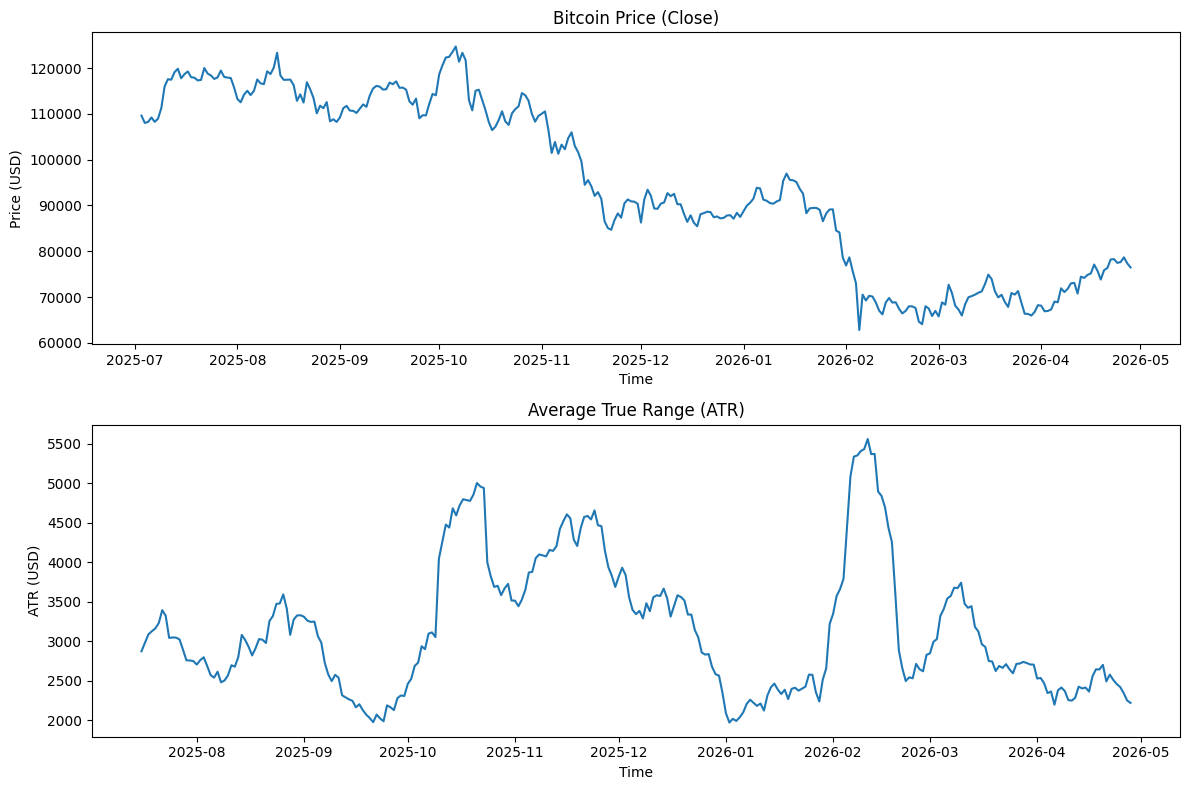

SUMMARY
remaining_cash: 95067.60972685888
total_equity: 100753.90002888614
realized_pnl: 67.60972685884758
unrealized_pnl: 686.2903020272637
num_trades: 89

BUYS


,time,strategy,entry_price,usd_spent,btc_bought
0,2025-07-16 00:00:00+00:00,swing_trading,118681.68,10000.0,0.084259
1,2025-07-25 00:00:00+00:00,swing_trading,117633.27,10000.0,0.085010
2,2025-08-07 00:00:00+00:00,swing_trading,117515.49,10000.0,0.085095
3,2025-08-22 00:00:00+00:00,swing_trading,116908.68,10000.0,0.085537
4,2025-08-25 00:00:00+00:00,value_investing,110127.74,5000.0,0.045402



SELLS


,time,strategy,type,position_id,entry_price,exit_price,btc_sold,usd_received,pnl,regime_at_exit
0,2025-07-25 00:00:00+00:00,swing_trading,stop_loss,1,118681.68,115808.274286,0.084259,9757.889700,-242.110300,swing_trading
1,2025-08-01 00:00:00+00:00,swing_trading,stop_loss,2,117633.27,114585.076429,0.085010,9740.873175,-259.126825,value_investing
2,2025-08-11 00:00:00+00:00,swing_trading,take_profit,3,117515.49,120130.345000,0.021274,2555.627879,55.627879,swing_trading
3,2025-08-13 00:00:00+00:00,swing_trading,take_profit,3,117515.49,122745.200000,0.021274,2611.255759,111.255759,swing_trading
4,2025-08-18 00:00:00+00:00,swing_trading,stop_loss,3,117515.49,114900.635000,0.042548,4888.744241,-111.255759,swing_trading



OPEN POSITIONS


,position_id,strategy,market_value,unrealized_pnl
0,34,value_investing,2.852484e+03,3.524841e+02
1,35,value_investing,2.833806e+03,3.338062e+02
2,36,value_investing,5.306521e-13,8.222062e-14
3,38,value_investing,5.306521e-13,5.805620e-14
4,39,value_investing,5.306521e-13,7.288933e-14


In [15]:
# Execute strategy

if __name__ == "__main__":
    
    # Fetch BTC data from Coinbase API
    candles_df = get_btc_historical_candles(product_id = "BTC-USD", granularity = 86400, 
                                            days_back = 300)
    print("\nImported BTC data")
    display(candles_df.head())

    # Calculate ATR over 2 weeks
    candles_df = calculate_atr(candles_df, window = 14)
    
    print("\nBTC ATR values")
    display(candles_df.iloc[14:19])

    # Plot BTC price and ATR
    plot_price_and_atr(candles_df)

    # Set value investing and swing trading parameters
    dca_params = {"buy_amount": 5000.0, "drop_trigger": 0.03, "atr_mult": 2.0,
                  "tp_levels": (1,2,3), "tp_fracs": (0.25, 0.25, 0.50)}

    swing_params = {"buy_amount": 10000.0, "atr_mult": 1.0, 
                    "tp_levels": (1, 2, 3),"tp_fracs": (0.25, 0.25, 0.50)}

    portfolio, df_out = run_strategy_loop(candles_df, total_budget=100000.0, dca_params=dca_params,
                                          swing_params=swing_params)

    buys_df, sells_df, open_df, summary = build_summary(portfolio, df_out)
    
    print("SUMMARY")
    for k, v in summary.items():
        print(f"{k}: {v}")

    print("\nBUYS")
    display(buys_df.head())

    print("\nSELLS")
    display(sells_df.head())

    print("\nOPEN POSITIONS")
    display(open_df.head())